# Heart Disease Machine Learning Model
To recap, many Singaporeans with chronic conditions are left unsupported between clinic visits. This is an issue as coronary artery disease is the biggest cause of death in Singapore.

As part of the project, my task is to develop a machine learning model to predict a patient’s risk of coronary artery disease – the most common type of heart disease, and to be integrated in an application. The aim to encourage check-ups when the models detect the presence of CAD.

Due to the clinical setting, we will prioritise Recall (Sensitivity) as a False Negative can prevent a patient from seeking life-saving care. The probabilities will be furtheres categories into Low, Moderate, and High risks with varying probability levels.
- Low - Unlikely presence of CAD
- Moderate - Checkup encouraged, but avoid panic
- High - Likely that CAD is present, checkup is urgent

## Data Collection
Link: https://archive.ics.uci.edudataset//45/heart+disease
We will used all 4 of the processed datasets from: Cleveland (US), Long Beach (US), Switzerland, and Hungary.

The data has the following features:

```age, gender, chest pain type, resting blood pressure, cholestrol levels, fasting blood sugar, resting electrocardiographic results, maximum heart rate achieved, exercise induced angina, oldpeak (ST depression induced by exercise relative to rest), the slope of the peak exercise ST segment, number of major vessels (0-3) colored by flourosopy, and thallium heart stress test``` to predict the presence of coronary artery disease.

While many of these variables cannot be measured at home, there will be some patients who have access due to other reasons. Due to differing target variables or inability to verify authencity, I have found that the UCI heart dataset is most relevant to our goals despite the flawed variables (the inability in measuring). Aside from Cleveland, adding other datasets is suitable as Virginia & Switzerland lacks data rows, which makes our model more robust against messy inputs.

## 1. Set-up & Importing Data
- Import dependencies
- Takes 4 datasets for variance
- Canonical columns for readability

In [226]:
# Uncomment the line below to install all required packages
# !pip install pandas numpy xgboost scikit-learn matplotlib seaborn missingno shap openpyxl 

# Data
import pandas as pd
import numpy as np
import os

# Modelling
from xgboost.sklearn import XGBClassifier
from sklearn.model_selection import StratifiedKFold, train_test_split, cross_val_predict, GridSearchCV
from sklearn.metrics import accuracy_score, recall_score, precision_score, confusion_matrix
from sklearn.calibration import calibration_curve
from sklearn.base import clone, copy
from sklearn.utils.class_weight import compute_sample_weight

# Imputation (MICE)
from sklearn.experimental import enable_iterative_imputer  # Required to enable IterativeImputer
from sklearn.impute import SimpleImputer, IterativeImputer
import joblib

# Visualisations
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno


In [10]:
canonical_columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

In [11]:
df_cleveland = pd.read_csv('../datasets/processed.cleveland.data')
df_virginia  = pd.read_csv('../datasets/processed.va.data')
df_hungary = pd.read_csv('../datasets/processed.hungarian.data')
df_swiss = pd.read_csv('../datasets/processed.switzerland.data')


FileNotFoundError: [Errno 2] No such file or directory: '../datasets/processed.cleveland.data'

### Direct download (alternative)

In [12]:
!pip install gdown

In [13]:
import gdown
import zipfile 
file_id = '15QTYRVbPuZzj9MoeBW3MZ7aWnDlIyFJL'
url = f'https://drive.google.com/uc?export=download&id={file_id}'
file_name = 'uci_heartdisease_4datasets.zip'
gdown.download(url, file_name, quiet=False)

output_dir = './datasets'
os.makedirs(output_dir, exist_ok=True)  # Creates folder if it does not exist

with zipfile.ZipFile(file_name, 'r') as zip_ref:
    zip_ref.extractall(output_dir)

df_cleveland = pd.read_csv(os.path.join(output_dir, 'processed.cleveland.data'))
df_virginia  = pd.read_csv(os.path.join(output_dir, 'processed.va.data'))
df_hungary   = pd.read_csv(os.path.join(output_dir, 'processed.hungarian.data'))
df_swiss     = pd.read_csv(os.path.join(output_dir, 'processed.switzerland.data'))


Downloading...
From: https://drive.google.com/uc?id=15QTYRVbPuZzj9MoeBW3MZ7aWnDlIyFJL
To: C:\Users\User\Documents\GitHub\aiappprj_test\uci_heartdisease_4datasets.zip
100%|██████████| 9.76k/9.76k [00:00<00:00, 16.2MB/s]


In [14]:
# Assign columns for readability
df_cleveland.columns = canonical_columns
df_virginia.columns = canonical_columns
df_hungary.columns = canonical_columns
df_swiss.columns = canonical_columns

## 2. Data Preparation & EDA (Processing)

### Strategy
As we are using XGBoost, we do not need data imputation or normalisation, as XGBoost has an innate Sparsity-Aware Split Finding algorithm.

### Combine datasets and view
- We are using all 4 datasets, we will do the splitting later.

In [15]:
# Merge datasets
df = pd.concat([df_cleveland, df_virginia, df_hungary, df_swiss], ignore_index=True)

Let's view the tabulated data and check the data types

In [16]:
df.iloc[np.r_[0:5, 900:905], :]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
1,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
2,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
3,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0
4,56.0,1.0,2.0,120.0,236.0,0.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,0
900,65.0,1.0,4.0,115,0,0,0,93,1,0,2,?,7,1
901,65.0,1.0,4.0,145,0,?,1,67,0,?,?,?,6,3
902,65.0,1.0,4.0,155,0,?,0,154,0,1,1,?,?,0
903,65.0,1.0,4.0,160,0,1,1,122,0,?,?,?,7,3
904,66.0,0.0,4.0,155,0,?,0,90,0,0,?,?,7,1


In [17]:
df.dtypes

age         float64
sex         float64
cp          float64
trestbps     object
chol         object
fbs          object
restecg      object
thalach      object
exang        object
oldpeak      object
slope        object
ca              str
thal            str
target        int64
dtype: object

There are missing values, and columns set as generic "object" datatypes. We will fix this.

### Fix & clean data values
- Replace ? values with NaN
- Replace 0 cholestrol with NaN
- Set all columns to float for consistency.

In [18]:
# Clean data
def clean_data(df):
    
    df = df.replace('?', np.nan)
    df['chol'] = df['chol'].replace(0, np.nan)
    
    # Convert all columns to float
    df = df.astype(float)
    return df

### Set target to binary (0/1)
- We will be measuring any presence of heart disease, not the severity. This is hence a binary classification.

In [19]:
def set_binary_target(df):
    df['target'] = (df['target'] > 0).astype(bool)
    return(df)

### One-hot encoding
- Chestpain and restecg have multiple values. To prevent correlation, we will use one-hot encoding.

In [20]:
def encode_data(df):
    df = pd.get_dummies(df, columns=['cp', 'restecg'], drop_first=True)
    return df

In [21]:
# We will finally use our data processing functions
df = clean_data(df)
df_clean_raw = df.copy()
df = set_binary_target(df)
df_noencode = df.copy()
df = encode_data(df)

### Verify changes

In [22]:
# See fixed missing values
df.iloc[np.r_[0:6, -5:0], :]

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,thal,target,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0
0,67.0,1.0,160.0,286.0,0.0,108.0,1.0,1.5,2.0,3.0,3.0,True,False,False,True,False,True
1,67.0,1.0,120.0,229.0,0.0,129.0,1.0,2.6,2.0,2.0,7.0,True,False,False,True,False,True
2,37.0,1.0,130.0,250.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,False,False,True,False,False,False
3,41.0,0.0,130.0,204.0,0.0,172.0,0.0,1.4,1.0,0.0,3.0,False,True,False,False,False,True
4,56.0,1.0,120.0,236.0,0.0,178.0,0.0,0.8,1.0,0.0,3.0,False,True,False,False,False,False
5,62.0,0.0,140.0,268.0,0.0,160.0,0.0,3.6,3.0,2.0,3.0,True,False,False,True,False,True
911,70.0,1.0,115.0,NaN,0.0,92.0,1.0,0.0,2.0,NaN,7.0,True,False,False,True,True,False
912,70.0,1.0,140.0,NaN,1.0,157.0,1.0,2.0,2.0,NaN,7.0,True,False,False,True,False,False
913,72.0,1.0,160.0,NaN,NaN,114.0,0.0,1.6,2.0,2.0,NaN,False,False,True,False,False,True
914,73.0,0.0,160.0,NaN,0.0,121.0,0.0,0.0,1.0,NaN,3.0,True,False,True,False,True,False


In [23]:
# See final variable types
df.dtypes

age            float64
sex            float64
trestbps       float64
chol           float64
fbs            float64
thalach        float64
exang          float64
oldpeak        float64
slope          float64
ca             float64
thal           float64
target            bool
cp_2.0            bool
cp_3.0            bool
cp_4.0            bool
restecg_1.0       bool
restecg_2.0       bool
dtype: object

In [24]:
print(df[df['chol'].isna()]['target'].value_counts(normalize=True))

target
True     0.822368
False    0.177632
Name: proportion, dtype: float64


## 3. Data Visualisation

In [149]:
def count_classes(df):
    count_0 = (df['target'] == 0).sum()
    # Count where target is 1
    count_1 = (df['target'] == 1).sum()
    print(count_0, count_1)
count_classes(df)

409 507


### Missing plot
We can visualise the missing values by row. This will help in our app building as we can identify the common missing values.

<Figure size 1200x700 with 0 Axes>

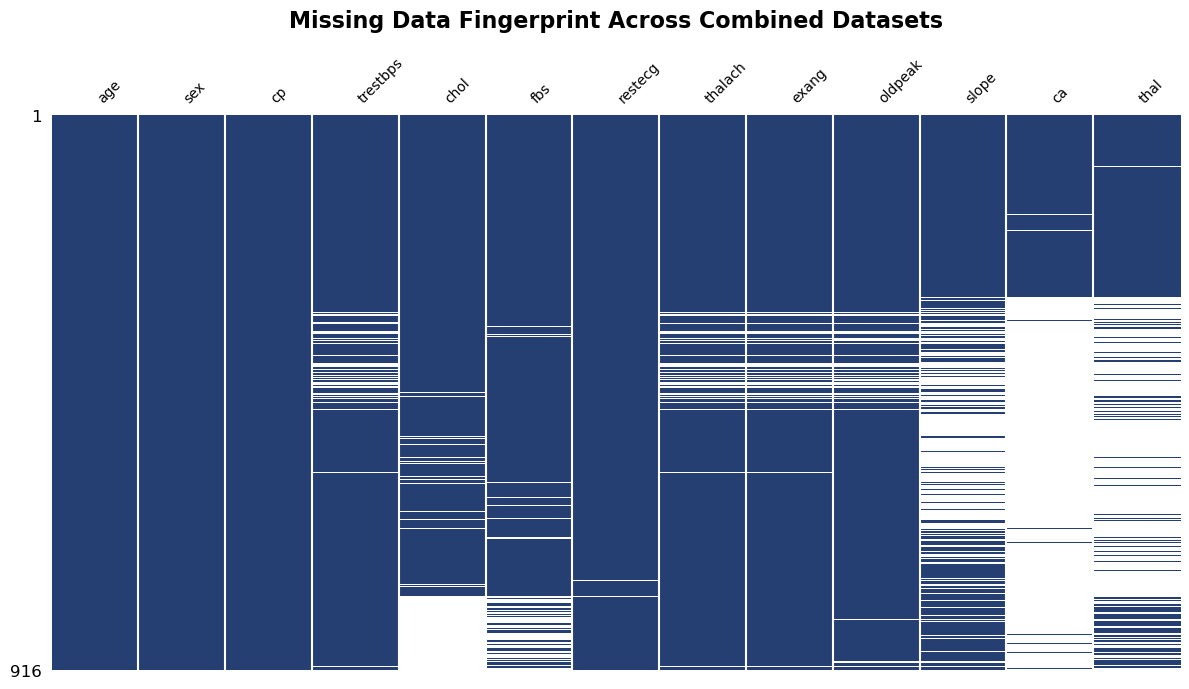

In [15]:
# Generate matrix
plt.figure(figsize=(12, 7))

# Set sparkline=False to keep the layout clean, and pass our dataframe & filter out 'target'
msno.matrix(
    df_noencode.drop(columns=['target']), 
    sparkline=False,
    figsize=(12, 7),
    fontsize=10,
    color=(0.15, 0.25, 0.45) # Classic slate blue for data present
)

plt.title('Missing Data Fingerprint Across Combined Datasets', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()


## 4. Model Testing
XGBoost (Extreme Gradient Boosting) is considered a gold standard in clinical due to its ability in "analysing tabular electronic health records." In addition to their missing value data handling, the callibrated probability allows us to override the standard 0.5 decision and set custom risk thresholds.

Data split

In [212]:
# Separate features and target
X = df.drop(columns=['target'])
y = df['target'].astype(int)

# Take 20% for test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Balance class dis.
sample_weights = compute_sample_weight(
    class_weight="balanced", y=y_train
)

## 4.0 Imputation
Imputation is actually needed as the model can falsely draw something from a value being NaN. This may work in a medical setting but not for our target audience.

In [230]:
# 1. Setup the MICE Imputer
# (Run this during your model training phase)
mice_imputer = IterativeImputer(random_state=42, max_iter=10)

# 2. Fit and transform your training data
X_train = pd.DataFrame(
    mice_imputer.fit_transform(X_train), 
    columns=X_train.columns
)

imputer_for_export = copy.deepcopy(mice_imputer)

X_test = pd.DataFrame(
    mice_imputer.transform(X_test), 
    columns=X_test.columns
)

X_final = pd.DataFrame(
    mice_imputer.transform(X), 
    columns=X.columns
)


In [236]:
X_final.iloc[np.r_[-15:0], :]

,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,thal,cp_2.0,cp_3.0,cp_4.0,restecg_1.0,restecg_2.0
901,65.0,1.0,145.000000,207.781828,0.250661,67.000000,0.000000,0.291865,2.026080,1.100184,6.000000,0.0,0.0,1.0,1.0,0.0
902,65.0,1.0,155.000000,246.698830,0.292397,154.000000,0.000000,1.000000,1.000000,1.063214,5.510048,0.0,0.0,1.0,0.0,0.0
903,65.0,1.0,160.000000,235.614535,1.000000,122.000000,0.000000,0.690570,1.834711,1.193336,7.000000,0.0,0.0,1.0,1.0,0.0
904,66.0,0.0,155.000000,220.875294,0.315684,90.000000,0.000000,0.000000,1.921553,1.078473,7.000000,0.0,0.0,1.0,0.0,0.0
905,66.0,1.0,150.000000,226.191044,0.000000,108.000000,1.000000,2.000000,2.000000,1.277656,7.000000,0.0,0.0,1.0,0.0,0.0
906,67.0,1.0,145.000000,231.125252,0.000000,125.000000,0.000000,0.000000,2.000000,0.747684,3.000000,0.0,0.0,0.0,0.0,1.0
907,68.0,1.0,135.000000,225.053971,0.000000,120.000000,1.000000,0.000000,1.000000,1.198458,7.000000,0.0,0.0,1.0,1.0,0.0
908,68.0,1.0,145.000000,235.501680,0.234607,136.000000,0.000000,1.800000,1.000000,1.333221,5.654787,0.0,0.0,1.0,0.0,0.0
909,69.0,1.0,135.000000,229.073461,0.000000,130.000000,0.000000,0.000000,2.000000,1.101728,6.000000,0.0,0.0,1.0,0.0,0.0
910,69.0,1.0,141.101399,234.010918,0.000000,115.408196,0.708855,1.044308,1.980775,1.281725,7.000000,0.0,0.0,1.0,1.0,0.0


Our model is located here, this is where we tweak the parameters.

In [214]:
# Model
model = XGBClassifier(
    n_estimators=1000,          # Number of trees
    learning_rate=0.018,        # Learning rate
    reg_lambda=0.95,            # Lambda (L2 regularization)
    max_depth=5,               # Limit depth of individual trees
    subsample=0.95,             # Fraction of training instances (row subsampling)
    colsample_bytree=0.5,      # Fraction of features for each tree
    gamma=5,
    min_child_weight=6,
    colsample_bylevel=1.0,     # Fraction of features for each level
    colsample_bynode=0.8,      # Fraction of features for each split
    
    # Structural parameters
    random_state=42,
    objective='binary:logistic',
    eval_metric='logloss'
)

#  {'colsample_bytree': 0.5, 'gamma': 5, 'min_child_weight': 6, 'reg_lambda': 0.95, 'subsample': 0.95} 0.885491 0.002557



## 4.1 Estimator & Learning Rate Test

In [185]:
def run_seed_stability_search(base_model, param_grid, seeds, X_train, y_train, scoring='average_precision'):
    """Run GridSearchCV across multiple seeds and summarise how stable each
    parameter combination's score is across seeds. Reused in 4.1 and 4.3."""
    all_results = []

    for seed in seeds:
        print(f"\n--- Running GridSearchCV for Seed: {seed} ---")

        # Clone the base model and dynamically update its random state
        test_model = clone(base_model)
        test_model.set_params(random_state=seed)

        # Set up cross-validation with the current seed
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)

        grid_search = GridSearchCV(
            estimator=test_model,
            param_grid=param_grid,
            scoring=scoring, # Optimizes the entire PR Curve space!
            cv=cv,
            n_jobs=-1,
            verbose=1
        )
        grid_search.fit(X_train, y_train, sample_weight=sample_weights)

        # Save results to a DataFrame and record the current seed
        res = pd.DataFrame(grid_search.cv_results_)
        res['seed'] = seed
        all_results.append(res)

    # Combine results from all seeds
    final_results = pd.concat(all_results, ignore_index=True)
    final_results['params_str'] = final_results['params'].astype(str)

    # Mean/std performance of each parameter set across all seeds
    stability_summary = (
        final_results.groupby('params_str')['mean_test_score']
        .agg(['mean', 'std'])
        .reset_index()
        .sort_values(by='mean', ascending=False)
    )

    return final_results, stability_summary


In [116]:
# Seeds and grid for the estimator / learning-rate sweep
seeds = [11, 33, 42, 44, 249, 727, 3000, 6769]  # Add as many seeds as you want to test
param_grid = {
    'n_estimators': [200, 225, 250, 300, 500, 600, 700, 800, 900, 1000],
    'learning_rate': [0.01, 0.015, 0.0175, 0.018, 0.02, 0.025, 0.04, 0.045, 0.05, 0.055, 0.06, 0.08, 0.1]
}

'''param_grid = {
    'n_estimators': [150, 160, 175, 180, 190, 200, 210, 220, 225, 250, 300, 400, 500, 600], # Realistic ranges
    'learning_rate': [0.014, 0.015, 0.016, 0.0175, 0.018, 0.02, 0.03, 0.04, 0.05] # Normal learning rates
}'''

final_results, stability_summary = run_seed_stability_search(model, param_grid, seeds, X_train, y_train)

print("\n--- Top 5 Most Stable Hyperparameter Combinations Across All Seeds ---")
print(stability_summary.head(5).to_string(index=False))



--- Running GridSearchCV for Seed: 11 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 33 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 42 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 44 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 249 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 727 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 3000 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Running GridSearchCV for Seed: 6769 ---
Fitting 5 folds for each of 130 candidates, totalling 650 fits

--- Top 5 Most Stable Hyperparameter Combinations Across All Seeds ---
                                    params_str     mean      std
{'learnin

## 4.2 Plot Results

In [117]:
# Extract the raw parameter values into separate columns
final_results['param_learning_rate'] = final_results['params'].apply(lambda x: x['learning_rate'])
final_results['param_n_estimators'] = final_results['params'].apply(lambda x: x['n_estimators'])

# Create the pivot tables for Mean and Standard Deviation
mean_pivot = final_results.pivot_table(
    index='param_n_estimators', 
    columns='param_learning_rate', 
    values='mean_test_score', 
    aggfunc='mean'
)

std_pivot = final_results.pivot_table(
    index='param_n_estimators', 
    columns='param_learning_rate', 
    values='mean_test_score', 
    aggfunc='std'
)


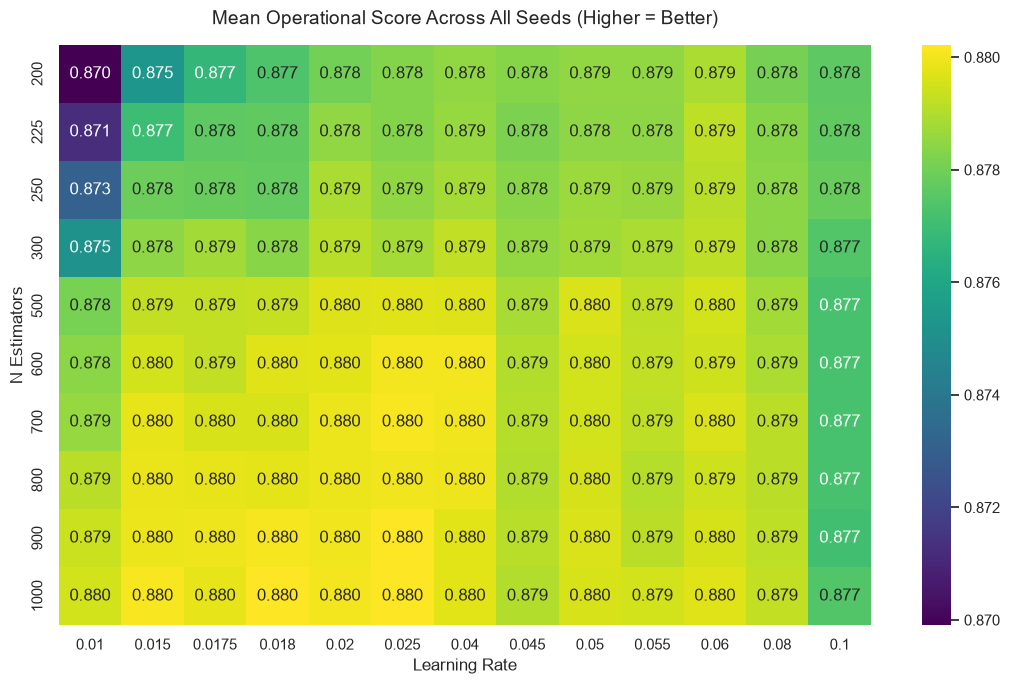

In [118]:
plt.figure(figsize=(11, 7))
sns.heatmap(mean_pivot, annot=True, fmt=".3f", cmap='viridis')

plt.title('Mean Operational Score Across All Seeds (Higher = Better)', fontsize=14, pad=15)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('N Estimators', fontsize=12)

plt.tight_layout()
plt.show()


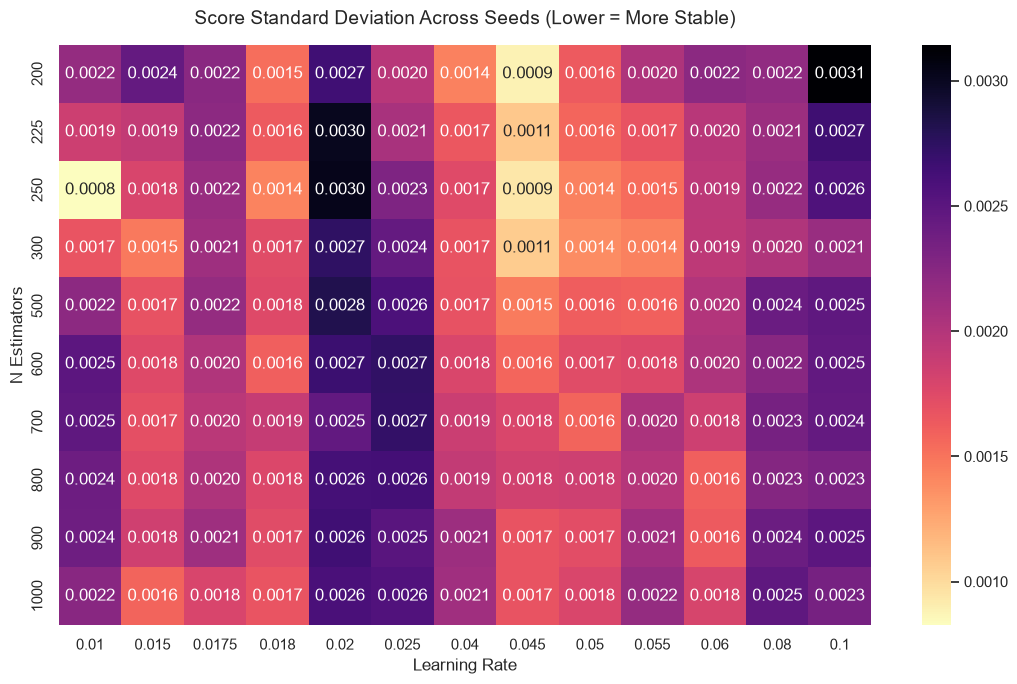

In [122]:
plt.figure(figsize=(11, 7))
# Using '_r' reverses the colormap so that lower variance looks darker/cooler
sns.heatmap(std_pivot, annot=True, fmt=".4f", cmap='magma_r')

plt.title('Score Standard Deviation Across Seeds (Lower = More Stable)', fontsize=14, pad=15)
plt.xlabel('Learning Rate', fontsize=12)
plt.ylabel('N Estimators', fontsize=12)

plt.tight_layout()
plt.show()

## 4.3 Test other hyperparameters
This will take a while.

In [114]:
# Seeds and grid for the remaining hyperparameters
seeds = [42, 123, 999]  # Add as many seeds as you want to test
param_grid = {
    'reg_lambda': [0.9, 0.91, 0.95, 1.0, 1.2, 1.5, 2],
    'colsample_bytree': [0.4, 0.5, 0.6],
    'subsample': [0.8, 0.85, 0.9, 0.95],
    'gamma': [1, 2, 3, 4, 5, 6, 7],
    'min_child_weight': [6, 7]
}

'''
param_grid = {
    'reg_lambda': [0.9, 0.91, 0.95, 1.0, 1.2],
    'colsample_bytree': [0.4, 0.5, 0.6],
    'subsample': [0.8, 0.9],
    'gamma': [1, 2, 3, 5, 7],
    'min_child_weight': [6, 7]
}
'''

final_results, stability_summary = run_seed_stability_search(model, param_grid, seeds, X_train, y_train)

print("\n--- Top 5 Most Stable Hyperparameter Combinations Across All Seeds ---")
print(stability_summary.head(5).to_string(index=False))



--- Running GridSearchCV for Seed: 42 ---
Fitting 5 folds for each of 1176 candidates, totalling 5880 fits

--- Running GridSearchCV for Seed: 123 ---
Fitting 5 folds for each of 1176 candidates, totalling 5880 fits

--- Running GridSearchCV for Seed: 999 ---
Fitting 5 folds for each of 1176 candidates, totalling 5880 fits

--- Top 5 Most Stable Hyperparameter Combinations Across All Seeds ---
                                                                                         params_str     mean      std
{'colsample_bytree': 0.5, 'gamma': 5, 'min_child_weight': 6, 'reg_lambda': 0.95, 'subsample': 0.95} 0.885491 0.002557
 {'colsample_bytree': 0.4, 'gamma': 5, 'min_child_weight': 6, 'reg_lambda': 1.0, 'subsample': 0.95} 0.884838 0.003017
 {'colsample_bytree': 0.5, 'gamma': 5, 'min_child_weight': 6, 'reg_lambda': 0.9, 'subsample': 0.95} 0.884775 0.003008
{'colsample_bytree': 0.4, 'gamma': 5, 'min_child_weight': 6, 'reg_lambda': 0.95, 'subsample': 0.95} 0.884743 0.003406
 {'colsample

## 4.4 Verify Results

In [201]:
# Final model uses the same tuned hyperparameters as `model` above
final_model = clone(model)
full_comprehensive_final_model = clone(final_model)

#   {'gamma': 2, 'max_depth': 4, 'reg_lambda': 1.1, 'subsample': 0.95} 0.910912 0.002925
#  {'colsample_bytree': 0.4, 'gamma': 1.5, 'min_child_weight': 6, 'reg_lambda': 0.9, 'subsample': 1} 0.912309 0.002341


Set up our stratified K-fold

In [120]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

#### Stratified 5-Fold Cross Validation
This is where we test the model, across multiple seeds. This will take a longer time but reduces bias towards the model's random seed.

This layout allows us to have every patient profile act as unseen validation data once, reducing data-leakage issues.

We will primarily focus on Recall (Sensitivity) to minimise False Negatives. Accuracy & Precision will be recorded and considered.

In [215]:
# Define your found optimal threshold here (from your PR/ROC curve analysis)
# Replace this value with the one found during your step 2 step
best_th = 0.4

# Verify datasets
print(f"Training/Validation Set: {X_train.shape[0]} rows")
print(f"Holdout Test Set: {X_test.shape[0]} rows\n")
print(f"Validating performance using Custom Threshold: {best_th}\n")

# List of test seeds
seeds = [1, 21, 42, 123, 727, 999, 922489021]

# Master lists to track the overall performance of each seed
seed_accuracies, seed_recalls, seed_precisions, seed_fprs = [], [], [], []

# Test for metrics across seeds
for seed in seeds:
    # Stratify your folds based on the current seed
    skf_seed = StratifiedKFold(n_splits=10, shuffle=True, random_state=seed)

    
    fold_accuracies = []
    fold_recalls = []
    fold_precisions = []
    fold_fprs = []
    
    for train_idx, val_idx in skf_seed.split(X_train, y_train):
        X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
        
        # Clone your baseline tuned model and update its internal random seed
        cv_model = clone(final_model)
        cv_model.set_params(random_state=seed)
        
        sample_weights_fold = compute_sample_weight(
            class_weight="balanced", y=y_train_fold
        )
        # Train and get probabilities for the positive class (class 1)
        cv_model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights_fold)
        probs = cv_model.predict_proba(X_test_fold)[:, 1]
        
        # Apply your custom threshold to generate final predictions
        preds = (probs >= best_th).astype(int)
        
        # Track metrics evaluated against the custom threshold predictions
        fold_accuracies.append(accuracy_score(y_test_fold, preds))
        fold_recalls.append(recall_score(y_test_fold, preds))
        fold_precisions.append(precision_score(y_test_fold, preds))
        
        # Calculate False Positive Rate using the confusion matrix
        tn, fp, fn, tp = confusion_matrix(y_test_fold, preds).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fold_fprs.append(fpr)
        
    # Average the 5 folds for this seed and save the result
    seed_accuracies.append(np.mean(fold_accuracies))
    seed_recalls.append(np.mean(fold_recalls))
    seed_precisions.append(np.mean(fold_precisions))
    seed_fprs.append(np.mean(fold_fprs))

# Print out stability summary
print(f"Metrics across seed list (Threshold = {best_th})")
print(f"Mean Accuracy across all seeds: {np.mean(seed_accuracies):.4f} (Std Dev: {np.std(seed_accuracies):.4f})")
print(f"Mean Recall across all seeds : {np.mean(seed_recalls):.4f} (Std Dev: {np.std(seed_recalls):.4f})")
print(f"Mean Precision across all seeds: {np.mean(seed_precisions):.4f} (Std Dev: {np.std(seed_precisions):.4f})")
print(f"Mean FPR across all seeds      : {np.mean(seed_fprs):.4f} (Std Dev: {np.std(seed_fprs):.4f})\n")


Training/Validation Set: 732 rows
Holdout Test Set: 184 rows

Validating performance using Custom Threshold: 0.4

Metrics across seed list (Threshold = 0.4)
Mean Accuracy across all seeds: 0.8117 (Std Dev: 0.0060)
Mean Recall across all seeds : 0.8664 (Std Dev: 0.0046)
Mean Precision across all seeds: 0.8085 (Std Dev: 0.0060)
Mean FPR across all seeds      : 0.2565 (Std Dev: 0.0095)



## 4.5 Final Model
We will not use the test results to tweak the model. This is the FINAL evaluation of our model.

In [216]:
skf_final = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
sample_weights_final = compute_sample_weight(
    class_weight="balanced", y=y_train
)
complete_model = clone(final_model)
complete_model.fit(X_train, y_train, sample_weight=sample_weights_final)

# Final test
y_proba_final = cross_val_predict(complete_model, X_test, y_test, cv=skf_final, method='predict_proba')[:, 1]

# Package it cleanly for the scatter plot
final_results_df = pd.DataFrame({
    'Probability': y_proba_final,
    'Actual': y_test.values
}, index=X_test.index)
final_results_df['Predicted'] = (final_results_df['Probability'] >= 0.4).astype(int)

# 2. Calculate the metrics
mean_accuracy = accuracy_score(final_results_df['Actual'], final_results_df['Predicted'])
mean_recall = recall_score(final_results_df['Actual'], final_results_df['Predicted'])
mean_precision = precision_score(final_results_df['Actual'], final_results_df['Predicted'])

print("Cross-Validation Metrics (Threshold = 0.4)")
print(f"Mean Accuracy:  {mean_accuracy:.4f} - Overall Acc")
print(f"Mean Recall:    {mean_recall:.4f} - True Positive")
print(f"Mean Precision: {mean_precision:.4f} - Not False Positive")

Cross-Validation Metrics (Threshold = 0.4)
Mean Accuracy:  0.8207 - Overall Acc
Mean Recall:    0.9216 - True Positive
Mean Precision: 0.7899 - Not False Positive


In [217]:
os.makedirs("../exports", exist_ok=True)

complete_model.save_model("../exports/exported_model2.ubj")

In [231]:
#Export the imputer
joblib.dump(imputer_for_export, '../exports/exported_imputer.pkl')

['../exports/exported_imputer.pkl']

## 5. Visualise test results

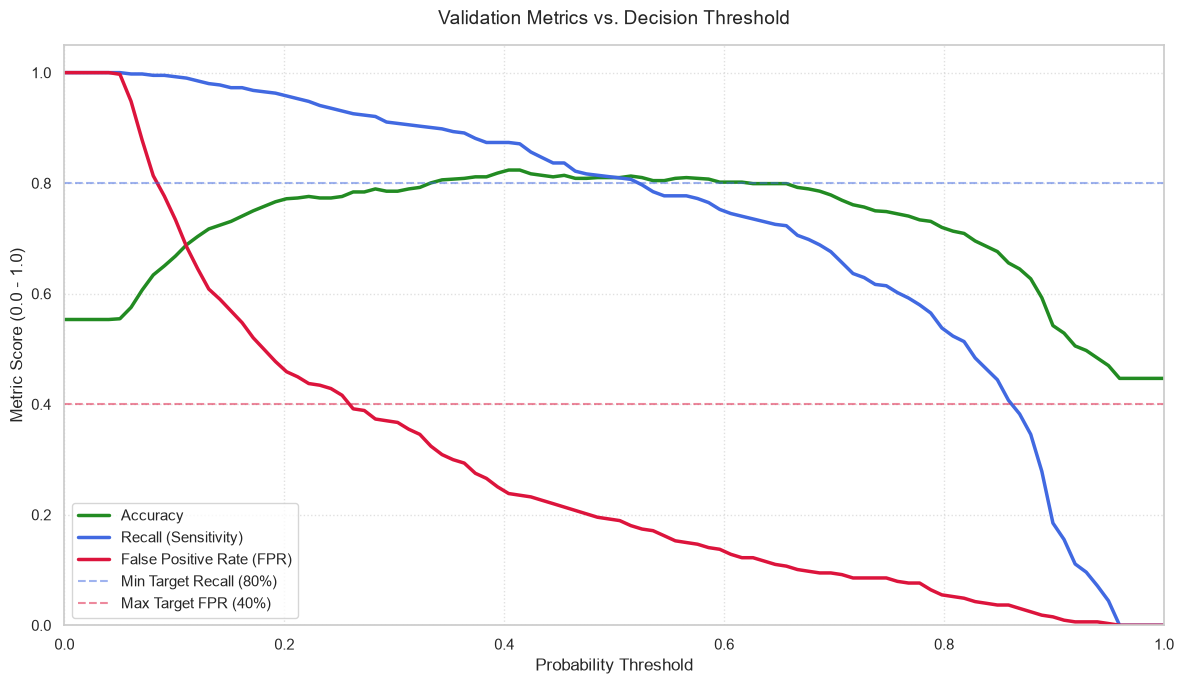

In [219]:
# 1. Use a single stable seed to generate the threshold curves across folds
plot_seed = 42
skf_plot = StratifiedKFold(n_splits=10, shuffle=True, random_state=plot_seed)

# Define the threshold resolution you want to test
threshold_grid = np.linspace(0.0, 1.0, 100)

# Lists to store the metrics computed at every threshold for each fold
all_fold_accuracies = []
all_fold_recalls = []
all_fold_fprs = []

for train_idx, val_idx in skf_plot.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    cv_model = clone(final_model)
    cv_model.set_params(random_state=plot_seed)
    sample_weights_fold = compute_sample_weight(
        class_weight="balanced", y=y_train_fold
    )
    # Train and get probabilities for the positive class (class 1)
    cv_model.fit(X_train_fold, y_train_fold, sample_weight=sample_weights_fold)
    
    # Get raw probabilities for the positive class
    probs = cv_model.predict_proba(X_test_fold)[:, 1]
    
    fold_accs, fold_recs, fold_fprs = [], [], []
    
    # Evaluate every threshold for this specific fold
    for th in threshold_grid:
        preds = (probs >= th).astype(int)
        
        # Calculate standard metrics
        fold_accs.append(accuracy_score(y_test_fold, preds))
        fold_recs.append(recall_score(y_test_fold, preds))
        
        # Calculate FPR
        tn, fp, fn, tp = confusion_matrix(y_test_fold, preds).ravel()
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
        fold_fprs.append(fpr)
        
    all_fold_accuracies.append(fold_accs)
    all_fold_recalls.append(fold_recs)
    all_fold_fprs.append(fold_fprs)

# Average the results across all 5 folds
mean_accuracies = np.mean(all_fold_accuracies, axis=0)
mean_recalls = np.mean(all_fold_recalls, axis=0)
mean_fprs = np.mean(all_fold_fprs, axis=0)

# 2. Plotting the single graph with 3 curves
plt.figure(figsize=(12, 7))

plt.plot(threshold_grid, mean_accuracies, label='Accuracy', color='forestgreen', linewidth=2.5)
plt.plot(threshold_grid, mean_recalls, label='Recall (Sensitivity)', color='royalblue', linewidth=2.5)
plt.plot(threshold_grid, mean_fprs, label='False Positive Rate (FPR)', color='crimson', linewidth=2.5)

# Highlight your clinical boundaries if desired
plt.axhline(y=0.80, color='royalblue', linestyle='--', alpha=0.5, label='Min Target Recall (80%)')
plt.axhline(y=0.40, color='crimson', linestyle='--', alpha=0.5, label='Max Target FPR (40%)')

plt.title('Validation Metrics vs. Decision Threshold', fontsize=14, pad=15)
plt.xlabel('Probability Threshold', fontsize=12)

plt.ylabel('Metric Score (0.0 - 1.0)', fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.05)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower left', fontsize=11)

plt.tight_layout()
plt.show()


Most visualisations will use the entire dataset.

In [220]:
# Get results of all
cv_results = cross_val_predict(complete_model, X_final, y, cv=skf_final, method='predict_proba')[:, 1]

# Package it cleanly for the scatter plot
cv_results_df = pd.DataFrame({
    'Probability': cv_results,
    'Actual': y.values
}, index=X_final.index)

cv_results_df['Predicted'] = (cv_results_df['Probability'] >= 0.4).astype(int)

In [221]:
cv_results_df.head(5)

,Probability,Actual,Predicted
0,0.868787,1,1
1,0.960678,1,1
2,0.369450,0,0
3,0.059587,0,0
4,0.083197,0,0


### Confusion Matrix with Risk Categories & Severity
Test data is used.
- Here we compare the model's predicted categories against the actual values.
- We also added manually adjusted categories based on the probability.
- The severity is also returned, this is to measure to what extend patients at the more severe level is misdiagnosed. Ideally our model will have minimal high-severity levels in the low risk category -- They are more likely to suffer long-term health consequences or death if we misclassify them as low risk and they fail to get checked.

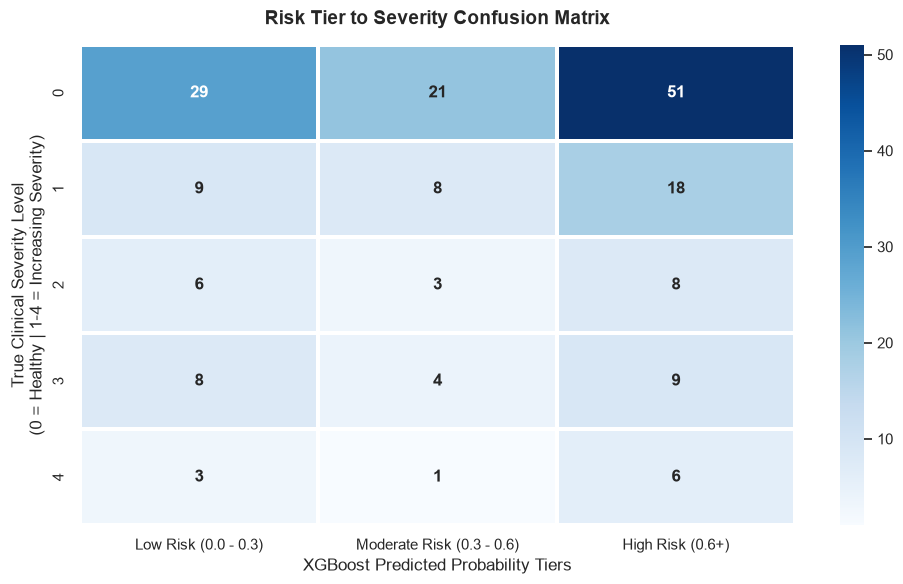

In [222]:
# 1. Clean the target column to ensure it contains numeric integers (0 to 4)
# (Using the index of final_results_df ensures we map the exact rows used in the model)
target_severity = pd.to_numeric(df_clean_raw.loc[final_results_df.index, 'target'], errors='coerce').fillna(0).astype(int)

# 2. Categorize your cross-validated probabilities into your exact boundaries
probability_tiers = pd.cut(
    final_results_df['Probability'],
    bins=[-np.inf, 0.30, 0.60, np.inf],
    labels=['Low Risk (0.0 - 0.3)', 'Moderate Risk (0.3 - 0.6)', 'High Risk (0.6+)']
)

# 3. Build the confusion cross-tabulation matrix
# Row (y-axis) will be true clinical severity; Column (x-axis) will be predicted app tier
matrix_df = pd.crosstab(
    index=target_severity,
    columns=probability_tiers,
    dropna=False
)

# 4. Plot the Matrix as a Heatmap
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

sns.heatmap(
    matrix_df,
    annot=True,         # Show the actual patient counts inside the boxes
    fmt='d',            # Format as integers
    cmap='Blues',       # Clean professional color gradient
    cbar=True,
    linewidths=1.5,
    annot_kws={"size": 12, "weight": "bold"}
)

plt.title('Risk Tier to Severity Confusion Matrix', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('True Clinical Severity Level\n(0 = Healthy | 1-4 = Increasing Severity)', fontsize=12)
plt.xlabel('XGBoost Predicted Probability Tiers', fontsize=12)

plt.tight_layout()
plt.show()

### Feature weightage
Visualises importance (weightage) of each variable by the XGBoost model

In [223]:
def plot_xgboost_feature_importance(trained_model, feature_names):
    # 1. Extract importances and map them to feature names
    importance_scores = trained_model.feature_importances_
    
    importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importance_scores
    }).sort_values(by='Importance', ascending=False)

    # 2. Plotting Setup
    plt.figure(figsize=(10, 6))
    sns.set_theme(style="whitegrid")
    
    # 3. Create Bar Chart
    sns.barplot(
        data=importance_df,
        x='Importance',
        y='Feature',
        palette="viridis",
        hue='Feature',
        legend=False
    )
    
    # 4. Refine Labels
    plt.title('Feature Weightage', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Weightage (0.01 = 1%)', fontsize=12)
    plt.ylabel('Feature', fontsize=12)
    
    plt.tight_layout()
    plt.show()

plot_xgboost_feature_importance(final_model, X_test.columns)


NotFittedError: need to call fit or load_model beforehand

The top variables: chest pain and exercise-induced angina, is slightly tricky to measure, but doable with an at-home questionnaire.

### Risk Distribution & Tier Categorisation
- Show distribution of patient risk probability, separated by actual diagnosis
- This is like the confusion matrix but with the probability.
- This is to visualise the coverage of categories.

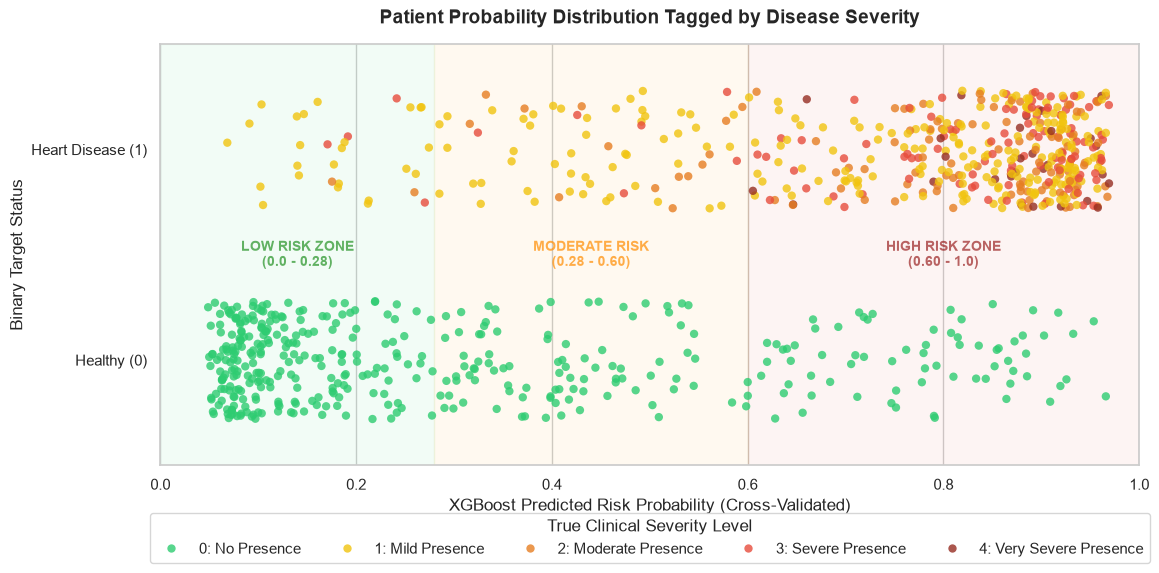

In [224]:
# Top is test, bottom is cv
# this_results = final_results_df.copy()
this_results = cv_results_df.copy()

# Extract the temporary severity series matching cv_results_df's index 
# (This keeps cv_results_df untouched)
temp_severity = pd.to_numeric(df_clean_raw.loc[this_results.index, 'target'], errors='coerce').fillna(0).astype(int)

# Create a clean label mapping dictionary
severity_labels = {
    0: '0: No Presence',
    1: '1: Mild Presence',
    2: '2: Moderate Presence',
    3: '3: Severe Presence',
    4: '4: Very Severe Presence'
}

# Gradient levels palette
severity_palette = {
    '0: No Presence': '#2ecc71',        # Bright Green
    '1: Mild Presence': '#f1c40f',       # Soft Yellow
    '2: Moderate Presence': '#e67e22',   # Warm Orange
    '3: Severe Presence': '#e74c3c',     # Medium Red
    '4: Very Severe Presence': '#962d22'   # Deep Crimson / Maroon
}

# Plotting
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Create the stripplot mapping both 'y' and 'hue' on-the-fly
sns.stripplot(
    data=this_results,
    x='Probability',
    y=this_results['Actual'].map({0: 'Healthy (0)', 1: 'Heart Disease (1)'}), 
    hue=temp_severity.map(severity_labels), # <--- Mapped dynamically here
    hue_order=['0: No Presence', '1: Mild Presence', '2: Moderate Presence', '3: Severe Presence', '4: Very Severe Presence'],
    jitter=0.28,
    size=6,
    alpha=0.8,
    palette=severity_palette
)

# Move legend cleanly to the bottom so it doesn't block the data points
plt.legend(title="True Clinical Severity Level", loc='lower center', bbox_to_anchor=(0.5, -0.25), ncol=5, frameon=True)

# Tier Risks
# Low Risk Zone (0.0 to 0.3)
plt.axvspan(0, 0.28, color='#2ecc71', alpha=0.06)
plt.text(0.14, 0.5, 'LOW RISK ZONE\n(0.0 - 0.28)', color='green', 
         fontsize=10, weight='bold', ha='center', va='center', alpha=0.6)

# Moderate Risk Zone (0.3 to 0.6)
plt.axvspan(0.28, 0.6, color='orange', alpha=0.06)
plt.text(0.44, 0.5, 'MODERATE RISK\n(0.28 - 0.60)', color='darkorange', 
         fontsize=10, weight='bold', ha='center', va='center', alpha=0.7)

# High Risk Zone (0.6 to 1.0)
plt.axvspan(0.6, 1.0, color='#e74c3c', alpha=0.06)
plt.text(0.80, 0.5, 'HIGH RISK ZONE\n(0.60 - 1.0)', color='darkred', 
         fontsize=10, weight='bold', ha='center', va='center', alpha=0.6)

# Labels and refining
plt.title('Patient Probability Distribution Tagged by Disease Severity', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('XGBoost Predicted Risk Probability (Cross-Validated)', fontsize=12)
plt.ylabel('Binary Target Status', fontsize=12)
plt.xlim(0, 1)

plt.tight_layout()
plt.show()


### Export results with features as xlsx
- This is to allow us to manually check the features of the patients the model misclassified.
- The goal is to check if even if we made the best model that we possibly can, we still won't be able to correctly classify with the data we have due to boundary cases -- having identical features to the incorrect class.


In [190]:
# 1. Map probabilities using the Index to guarantee perfect patient alignment
df_clean_raw['Predicted_Probability'] = cv_results_df['Probability']

# 2. Map the custom risk tiers using the securely mapped probability column
df_clean_raw['Assigned_Risk_Tier'] = df_clean_raw['Predicted_Probability'].apply(
    lambda p: 'Low Risk' if p <= 0.30 else ('Moderate Risk' if p <= 0.60 else 'High Risk')
)

# 3. Export to Excel (requires the openpyxl package -- see install cell at the top)
os.makedirs("../exports", exist_ok=True)
df_clean_raw.to_excel("../exports/heart_disease_raw_with_predictions.xlsx", index=False)

print("Data file securely exported. Saved as 'heart_disease_raw_with_predictions.xlsx'")


Data file securely exported. Saved as 'heart_disease_raw_with_predictions.xlsx'


## Probability Threshold

In [139]:
# 1. Initialize variables to collect all out-of-fold predictions
plot_seed = 42
skf_plot = StratifiedKFold(n_splits=5, shuffle=True, random_state=plot_seed)

all_true_labels = []
all_pred_probs = []

# 2. Loop through folds to collect true labels and predicted probabilities
for train_idx, val_idx in skf_plot.split(X_train, y_train):
    X_train_fold, X_test_fold = X_train.iloc[train_idx], X_train.iloc[val_idx]
    y_train_fold, y_test_fold = y_train.iloc[train_idx], y_train.iloc[val_idx]
    
    cv_model = clone(final_model)
    cv_model.set_params(random_state=plot_seed)
    cv_model.fit(X_train_fold, y_train_fold)
    
    # Get probabilities for the positive class
    probs = cv_model.predict_proba(X_test_fold)[:, 1]
    
    all_true_labels.extend(y_test_fold)
    all_pred_probs.extend(probs)

# 3. Calculate the calibration curve (binned probabilities)
# n_bins=10 breaks the 0.0 to 1.0 probability space into 10 intervals
prob_true, prob_pred = calibration_curve(all_true_labels, all_pred_probs, n_bins=10, strategy='uniform')


In [143]:
print(prob_pred)
print(prob_true)

[0.08088492 0.14668593 0.24485881 0.35334863 0.45296049 0.54624578
 0.65438471 0.74882543 0.85806031 0.92281449]
[0.04081633 0.08411215 0.1754386  0.34090909 0.39655172 0.53846154
 0.62962963 0.85507246 0.904      0.95726496]


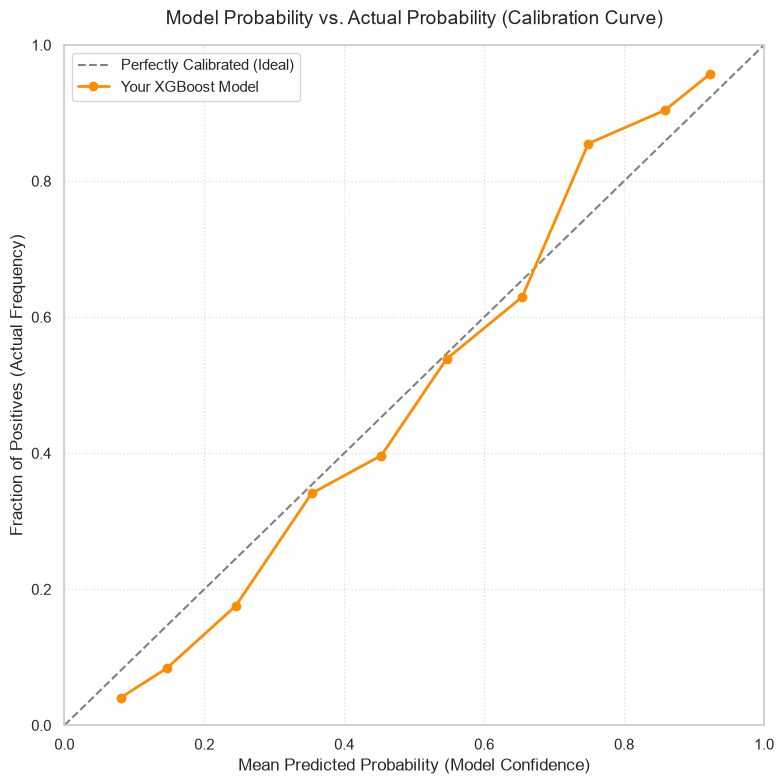

In [141]:
plt.figure(figsize=(8, 8))

# Plot the diagonal line representing a perfectly calibrated model
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly Calibrated (Ideal)')

# Plot your model's actual performance line
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, color='darkorange', label='Your XGBoost Model')

plt.title('Model Probability vs. Actual Probability (Calibration Curve)', fontsize=14, pad=15)
plt.xlabel('Mean Predicted Probability (Model Confidence)', fontsize=12)
plt.ylabel('Fraction of Positives (Actual Frequency)', fontsize=12)
plt.xlim(0.0, 1.0)
plt.ylim(0.0, 1.0)
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='upper left', fontsize=11)

plt.tight_layout()
plt.show()